In [1]:
import scanpy as sc
import pandas as pd
import scipy.io as scipy
import celltypist
from celltypist import models
import anndata
import matplotlib.pyplot as plt

In [2]:
matrix = scipy.mmread('/Users/gagled01/morganLab/single-cell/CITE_Study/objects/cellTypist_rawMaterials/T2_MoMacs_forMiloAnalysis_sparseMatrix.mtx')
gene_list = pd.read_table('/Users/gagled01/morganLab/single-cell/CITE_Study/objects/cellTypist_rawMaterials/T2_MoMacs_forMiloAnalysis_geneNames.txt', header = None)
cell_list = pd.read_table('/Users/gagled01/morganLab/single-cell/CITE_Study/objects/cellTypist_rawMaterials/T2_MoMacs_forMiloAnalysis_cellNames.txt', header = None)

In [4]:
models.download_models(force_update = True)
model = models.Model.load(model = 'Immune_All_Low.pkl') # low hierarchy = high resolution

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 18
📂 Storing models in /Users/gagled01/.celltypist/data/models
💾 Downloading model [1/18]: Immune_All_Low.pkl
💾 Downloading model [2/18]: Immune_All_High.pkl
💾 Downloading model [3/18]: Adult_Mouse_Gut.pkl
💾 Downloading model [4/18]: Autopsy_COVID19_Lung.pkl
💾 Downloading model [5/18]: COVID19_Immune_Landscape.pkl
💾 Downloading model [6/18]: Cells_Fetal_Lung.pkl
💾 Downloading model [7/18]: Cells_Intestinal_Tract.pkl
💾 Downloading model [8/18]: Cells_Lung_Airway.pkl
💾 Downloading model [9/18]: Developing_Human_Brain.pkl
💾 Downloading model [10/18]: Developing_Human_Thymus.pkl
💾 Downloading model [11/18]: Developing_Mouse_Brain.pkl
💾 Downloading model [12/18]: Healthy_COVID19_PBMC.pkl
💾 Downloading model [13/18]: Human_IPF_Lung.pkl
💾 Downloading model [14/18]: Human_Lung_Atlas.pkl
💾 Downloading model [15/18]: Human_PF_Lung.pkl
💾 Downloading model [16/18]: Lethal_COVID19_Lung

In [5]:
# need to put absolute path in here apparently...bugs out if i use variable to path, despite the tutorial using a variable
# also need gene and cell files for this

# important to transpose so that the files match up
matrix = matrix.T 
predictions = celltypist.annotate(filename = '/Users/gagled01/morganLab/single-cell/CITE_Study/objects/cellTypist_rawMaterials/T2_MoMacs_forMiloAnalysis_sparseMatrix.mtx',
                                  gene_file = '/Users/gagled01/morganLab/single-cell/CITE_Study/objects/cellTypist_rawMaterials/T2_MoMacs_forMiloAnalysis_geneNames.txt',
                                  cell_file = '/Users/gagled01/morganLab/single-cell/CITE_Study/objects/cellTypist_rawMaterials/T2_MoMacs_forMiloAnalysis_cellNames.txt',
                                  model = 'Immune_All_Low.pkl', majority_voting = True, transpose_input = True)

📁 Input file is '/Users/gagled01/morganLab/single-cell/CITE_Study/objects/cellTypist_rawMaterials/T2_MoMacs_forMiloAnalysis_sparseMatrix.mtx'
⏳ Loading data
⚠️ Warning: the input file seems not a raw count matrix. The prediction result may be biased
🔬 Input data has 45451 cells and 30749 genes
🔗 Matching reference genes in the model
🧬 6152 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!


In [6]:
predictions.predicted_labels
adata = predictions.to_adata()
adata.obs

,predicted_labels,over_clustering,majority_voting,conf_score
mix1.lib1_AAACCTGCACGAGAGT-1_1,Neutrophil-myeloid progenitor,147,Classical monocytes,0.028054
mix1.lib1_AAACGGGCATCGATGT-1_1,Classical monocytes,34,Classical monocytes,0.990971
mix1.lib1_AAACGGGGTGCAGTAG-1_1,Classical monocytes,43,Classical monocytes,0.953044
mix1.lib1_AAACGGGTCGATGAGG-1_1,Classical monocytes,43,Classical monocytes,0.047229
mix1.lib1_AAAGATGCAGTGAGTG-1_1,Classical monocytes,77,Classical monocytes,0.939198
...,...,...,...,...
mix10.lib2_TTGAACGGTAGCGTCC-1_10,Classical monocytes,50,Classical monocytes,0.991207
mix10.lib2_TTGAACGGTCCTCCAT-1_10,Classical monocytes,98,Classical monocytes,0.998355
mix10.lib2_TTGCGTCAGCCCAGCT-1_10,Classical monocytes,298,Classical monocytes,0.991031
mix10.lib2_TTGTAGGAGAGCTATA-1_10,Classical monocytes,182,Classical monocytes,0.805036


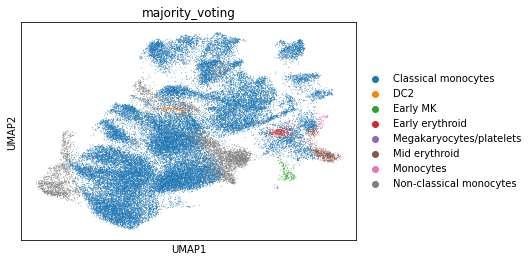

In [7]:
sc.tl.umap(adata)
sc.pl.umap(adata, color = ['majority_voting'], legend_loc = 'right margin', save = "T2_MoMacs_forMiloAnalysis_ImmuneLow2.png")
#fig.set_canvas(plt.gcf().canvas)


In [8]:
anndata.AnnData.write(adata, filename = '/Users/gagled01/morganLab/single-cell/CITE_Study/objects/T2_MoMacs_forMiloAnalysis.h5ad')

In [9]:
adata

AnnData object with n_obs × n_vars = 45451 × 30749
    obs: 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
    uns: 'log1p', 'neighbors', 'leiden', 'umap', 'majority_voting_colors'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'